In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/Users/alex.shtoff/git/spectral_neuron_paper


# Criteo scaling

Validation-selected test performance after one-pass training of the linear, factorization-machine, and spectral-neuron models. Curves with the same color use the same number of learned parameters per active feature; lower is better.

## Setup

In [2]:
import warnings

import matplotlib as mpl
import pandas as pd
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

from paper.experiments.criteo_scaling import (
    PROFILES,
    default_raw_path,
    select_lr,
    summarize_raw,
)
from paper.plotting import plot_criteo_scaling

mpl.rcParams["figure.dpi"] = 140

In [3]:
profile_name = "full"
profile = PROFILES[profile_name]
raw_path = default_raw_path(profile_name)

## Load and validate results

Preprocessing is fitted once on a fixed 10% sample of the training split. The test columns exist only for the learning rate selected on validation data. The checks below reject stale, incomplete, or mismatched experiment files before plotting.

In [4]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; run paper.experiments.criteo_scaling first"
    )

raw = pd.read_csv(raw_path)
required_identity = {"protocol", "preprocessor_sample_size", "preprocessor_seed"}
if not required_identity <= set(raw):
    raise ValueError(f"{raw_path} predates the one-pass protocol; rerun this profile")
if set(raw["protocol"]) != {"one_pass"}:
    raise ValueError(f"{raw_path} is not a one-pass scaling run")

expected_models = {"linear", "fm", "spectral"}
if set(raw["model"]) != expected_models:
    raise ValueError(f"{raw_path} does not contain exactly {sorted(expected_models)}")
if set(raw["train_size"]) != set(profile.train_sizes):
    raise ValueError(f"{raw_path} does not match the {profile_name!r} profile")

selected = select_lr(raw)
if selected[["test_logloss", "test_brier"]].isna().any().any():
    raise ValueError(f"{raw_path} has incomplete selected test results")

summary = summarize_raw(raw)
summary[[
    "train_size",
    "model",
    "matrix_dim",
    "fm_rank",
    "parameters_per_feature",
    "selected_lr",
    "median_test_logloss",
    "median_test_brier",
    "n",
]].sort_values(["train_size", "parameters_per_feature", "model"])

,train_size,model,matrix_dim,fm_rank,parameters_per_feature,selected_lr,median_test_logloss,median_test_brier,n
4,16384,linear,0,0,1,0.100000,0.520133,0.171729,3
0,16384,fm,0,5,6,0.026827,0.528766,0.174610,3
5,16384,spectral,3,0,6,0.051795,0.542524,0.180077,3
1,16384,fm,0,14,15,0.026827,0.533253,0.176222,3
6,16384,spectral,5,0,15,0.051795,0.540334,0.178607,3
...,...,...,...,...,...,...,...,...,...
69,36672493,spectral,5,0,15,0.026827,0.457785,0.148663,3
65,36672493,fm,0,44,45,0.013895,0.450639,0.146046,3
70,36672493,spectral,9,0,45,0.013895,0.458305,0.148839,3
66,36672493,fm,0,119,120,0.007197,0.449696,0.145684,3


## Scaling results

Lines show medians across initialization seeds; shaded regions span the 25th to 75th percentiles.

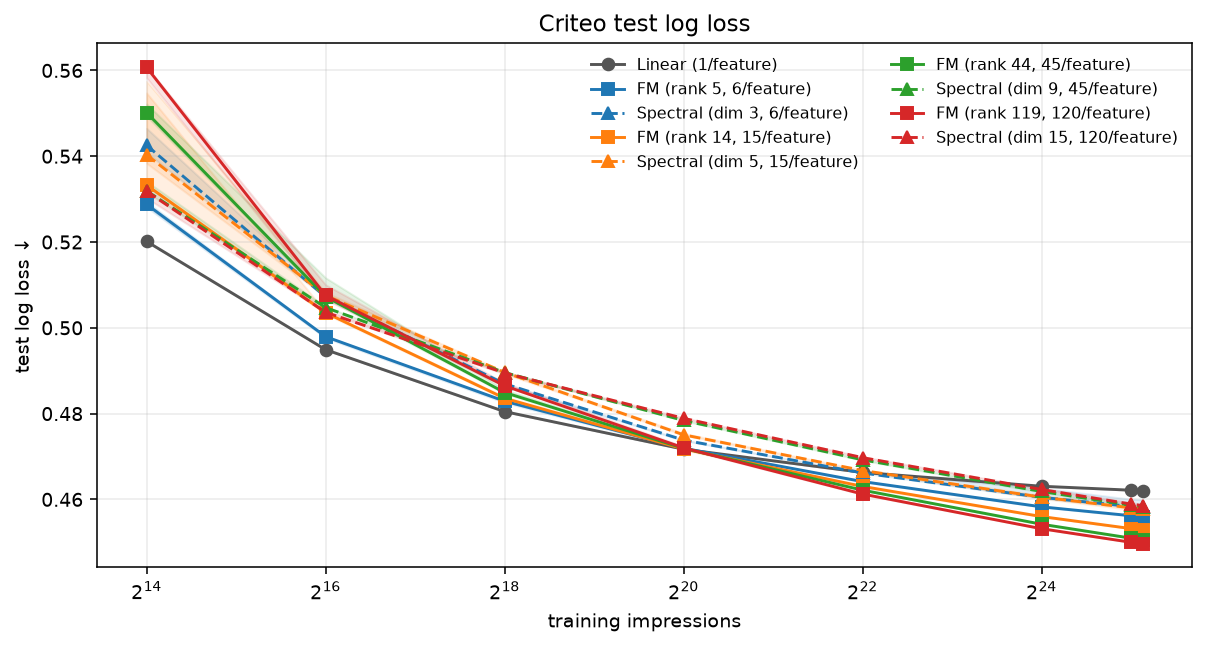

In [5]:
plot_criteo_scaling(summary, metric="logloss");

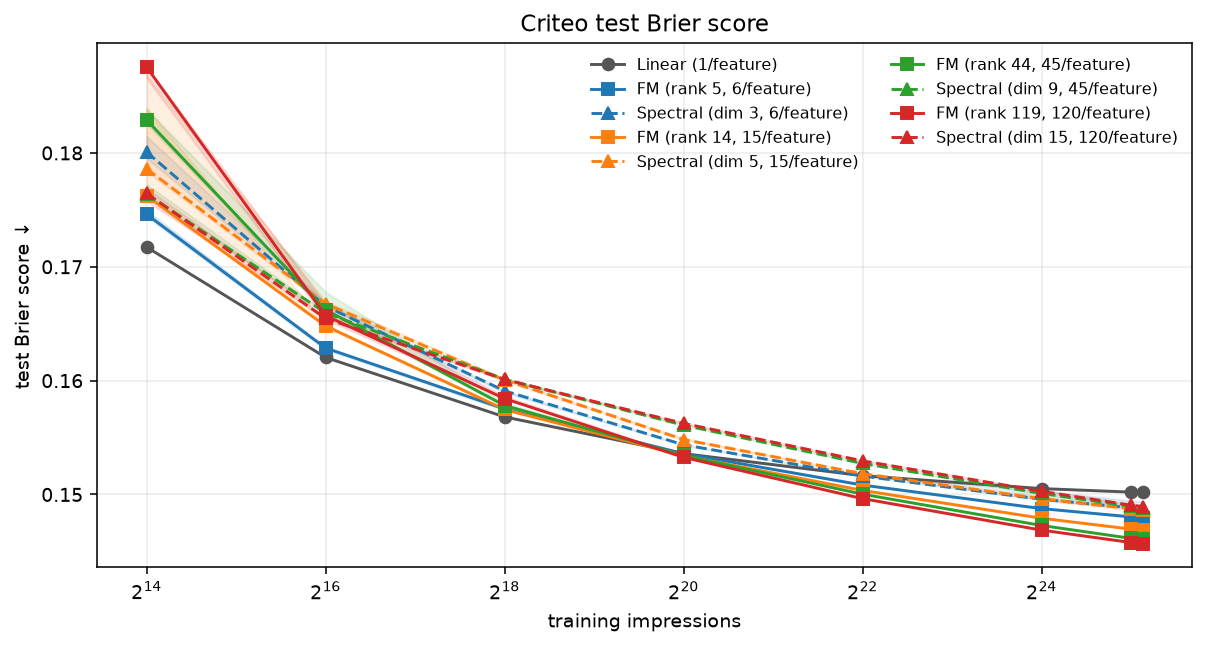

In [6]:
plot_criteo_scaling(summary, metric="brier");

## Reading the comparison

The gray curve is the linear baseline. Each solid FM curve and dashed spectral curve of the same color have matched per-feature parameter counts. This makes the vertical separation within a color the direct architectural comparison, while movement along the horizontal axis measures data scaling.